In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
store = pd.read_csv('/content/store.csv')
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0


In [2]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
train.shape

(1017209, 9)

In [3]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [4]:
store.shape

(1115, 10)

In [56]:
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0)
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0)
store['PromoInterval'] = store['PromoInterval'].fillna('None')

In [57]:

month_mode = store['CompetitionOpenSinceMonth'].mode()[0]
year_mode = store['CompetitionOpenSinceYear'].mode()[0]

store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(month_mode)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(year_mode)

In [7]:
store[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']]

,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1270.0,9.0,2008.0,0.0,0.0,None
1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,620.0,9.0,2009.0,0.0,0.0,None
4,29910.0,4.0,2015.0,0.0,0.0,None
...,...,...,...,...,...,...
1110,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1880.0,4.0,2006.0,0.0,0.0,None
1112,9260.0,9.0,2013.0,0.0,0.0,None
1113,870.0,9.0,2013.0,0.0,0.0,None


In [58]:
import pandas as pd
store = pd.read_csv('/content/store.csv') # Reload store if not defined

cols_to_int = [
    'CompetitionDistance',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2SinceWeek',
    'Promo2SinceYear'
]

# Fill NaN values in 'CompetitionDistance' with its median before converting to int
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

# Fill NaN values for CompetitionOpenSinceMonth and Year with their modes
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(store['CompetitionOpenSinceMonth'].mode()[0])
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(store['CompetitionOpenSinceYear'].mode()[0])

# Fill NaN values for Promo2SinceWeek and Year with 0
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0)
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0)

for col in cols_to_int:
    store[col] = store[col].astype(int)
print(store.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Store                      1115 non-null   int64 
 1   StoreType                  1115 non-null   object
 2   Assortment                 1115 non-null   object
 3   CompetitionDistance        1115 non-null   int64 
 4   CompetitionOpenSinceMonth  1115 non-null   int64 
 5   CompetitionOpenSinceYear   1115 non-null   int64 
 6   Promo2                     1115 non-null   int64 
 7   Promo2SinceWeek            1115 non-null   int64 
 8   Promo2SinceYear            1115 non-null   int64 
 9   PromoInterval              571 non-null    object
dtypes: int64(7), object(3)
memory usage: 87.2+ KB
None


In [9]:
# so we need to merge this 2 dataset , beacuse training data only sales record while store.csv contains store fix info without this we cant predict sales

df = train.merge(store, on='Store', how='left')

print('train :', train.shape)
print('store :', store.shape)
print('merged:', df.shape)


train : (280270, 9)
store : (1115, 10)
merged: (280270, 18)


In [10]:
df.shape

(280270, 18)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280270 entries, 0 to 280269
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      280270 non-null  int64  
 1   DayOfWeek                  280269 non-null  float64
 2   Date                       280269 non-null  object 
 3   Sales                      280269 non-null  float64
 4   Customers                  280269 non-null  float64
 5   Open                       280269 non-null  float64
 6   Promo                      280269 non-null  float64
 7   StateHoliday               280269 non-null  object 
 8   SchoolHoliday              280269 non-null  float64
 9   StoreType                  280270 non-null  object 
 10  Assortment                 280270 non-null  object 
 11  CompetitionDistance        280270 non-null  int64  
 12  CompetitionOpenSinceMonth  191191 non-null  float64
 13  CompetitionOpenSinceYear   19

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

,0
Store,0
DayOfWeek,1
Date,1
Sales,1
Customers,1
Open,1
Promo,1
StateHoliday,1
SchoolHoliday,1
StoreType,0


In [14]:
df['PromoInterval'] = df['PromoInterval'].fillna('None')

# Verify that there are no more missing values in the merged dataframe
print('Missing values in PromoInterval:', df['PromoInterval'].isnull().sum())
display(df.head())

Missing values in PromoInterval: 0


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0,c,a,1270,9.0,2008.0,0,NaN,NaN,None
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0,a,a,570,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0,a,a,14130,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0,c,c,620,9.0,2009.0,0,NaN,NaN,None
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0,a,a,29910,4.0,2015.0,0,NaN,NaN,None


In [15]:
df.shape


(280270, 18)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280270 entries, 0 to 280269
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      280270 non-null  int64  
 1   DayOfWeek                  280269 non-null  float64
 2   Date                       280269 non-null  object 
 3   Sales                      280269 non-null  float64
 4   Customers                  280269 non-null  float64
 5   Open                       280269 non-null  float64
 6   Promo                      280269 non-null  float64
 7   StateHoliday               280269 non-null  object 
 8   SchoolHoliday              280269 non-null  float64
 9   StoreType                  280270 non-null  object 
 10  Assortment                 280270 non-null  object 
 11  CompetitionDistance        280270 non-null  int64  
 12  CompetitionOpenSinceMonth  191191 non-null  float64
 13  CompetitionOpenSinceYear   19

In [17]:
df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0,c,a,1270,9.0,2008.0,0,NaN,NaN,None
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0,a,a,570,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0,a,a,14130,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0,c,c,620,9.0,2009.0,0,NaN,NaN,None
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0,a,a,29910,4.0,2015.0,0,NaN,NaN,None
5,6,5.0,2015-07-31,5651.0,589.0,1.0,1.0,0,1.0,a,a,310,12.0,2013.0,0,NaN,NaN,None
6,7,5.0,2015-07-31,15344.0,1414.0,1.0,1.0,0,1.0,a,c,24000,4.0,2013.0,0,NaN,NaN,None
7,8,5.0,2015-07-31,8492.0,833.0,1.0,1.0,0,1.0,a,a,7520,10.0,2014.0,0,NaN,NaN,None
8,9,5.0,2015-07-31,8565.0,687.0,1.0,1.0,0,1.0,a,c,2030,8.0,2000.0,0,NaN,NaN,None
9,10,5.0,2015-07-31,7185.0,681.0,1.0,1.0,0,1.0,a,a,3160,9.0,2009.0,0,NaN,NaN,None


### Univariate Analysis: Sales

In [18]:
print(df['Sales'].describe())


count    280269.000000
mean       5991.644695
std        3989.061157
min           0.000000
25%        3879.000000
50%        5990.000000
75%        8175.000000
max       41551.000000
Name: Sales, dtype: float64


Let's visualize the distribution of 'Sales' using a histogram and a box plot.

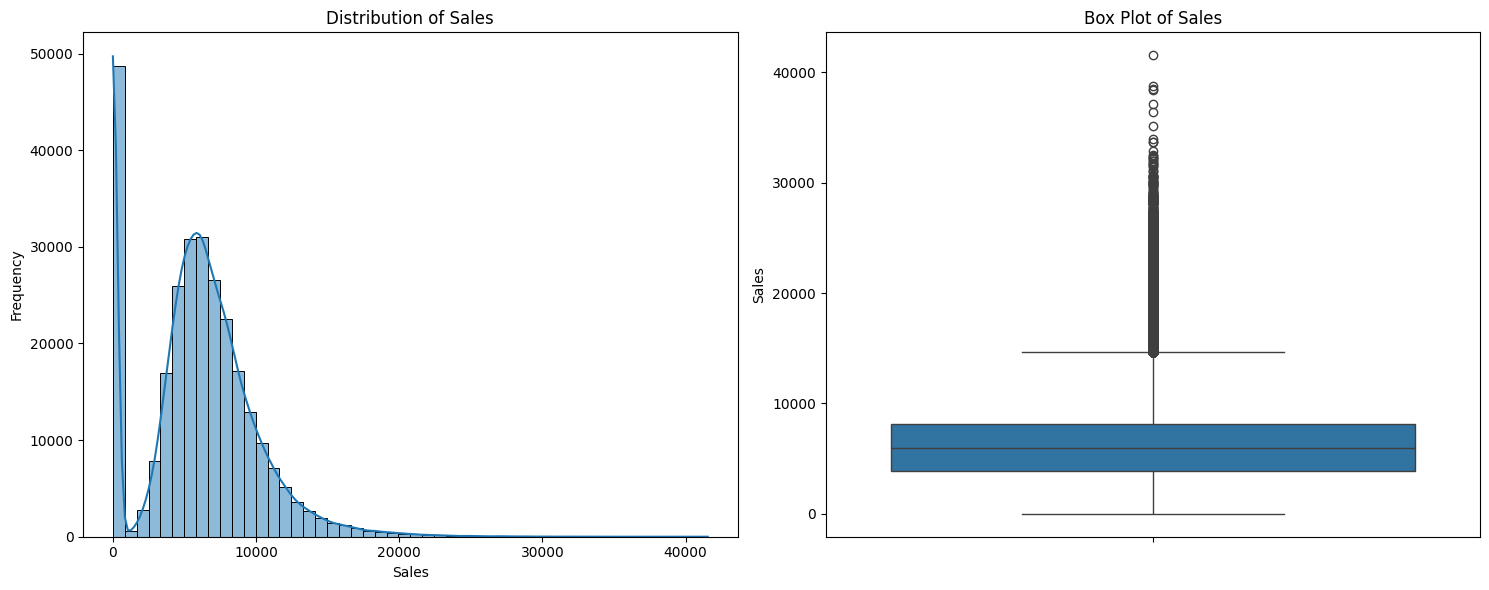

In [19]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Sales'], kde=True, bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Sales'])
plt.title('Box Plot of Sales')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()


In [20]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

print(f"Number of outliers in 'Sales': {len(outliers)}")
print(f"Percentage of outliers: {len(outliers) / len(df) * 100:.2f}%")


Number of outliers in 'Sales': 7101
Percentage of outliers: 2.53%


### Univariate Analysis: 'Sales' Column Summary

-   **Sales Distribution:** Right-skewed, indicating many low sales and fewer high sales days.
-   **Zero Sales:** Many instances of zero sales, likely due to store closures.
-   **Outliers:** Approximately 2.53% of sales are outliers (very high values), possibly from promotions or special events.
-   **Mean vs. Median:** Mean sales are slightly higher than the median, influenced by high sales outliers.

### Univariate Analysis: Customers Column

Let's start by looking at the descriptive statistics for the 'Customers' column.

In [21]:
print(df['Customers'].describe())

count    280269.000000
mean        634.869136
std         466.830818
min           0.000000
25%         410.000000
50%         614.000000
75%         839.000000
max        5458.000000
Name: Customers, dtype: float64


Ab hum 'Customers' column ke distribution ko visualize karenge ek histogram aur box plot ke through.

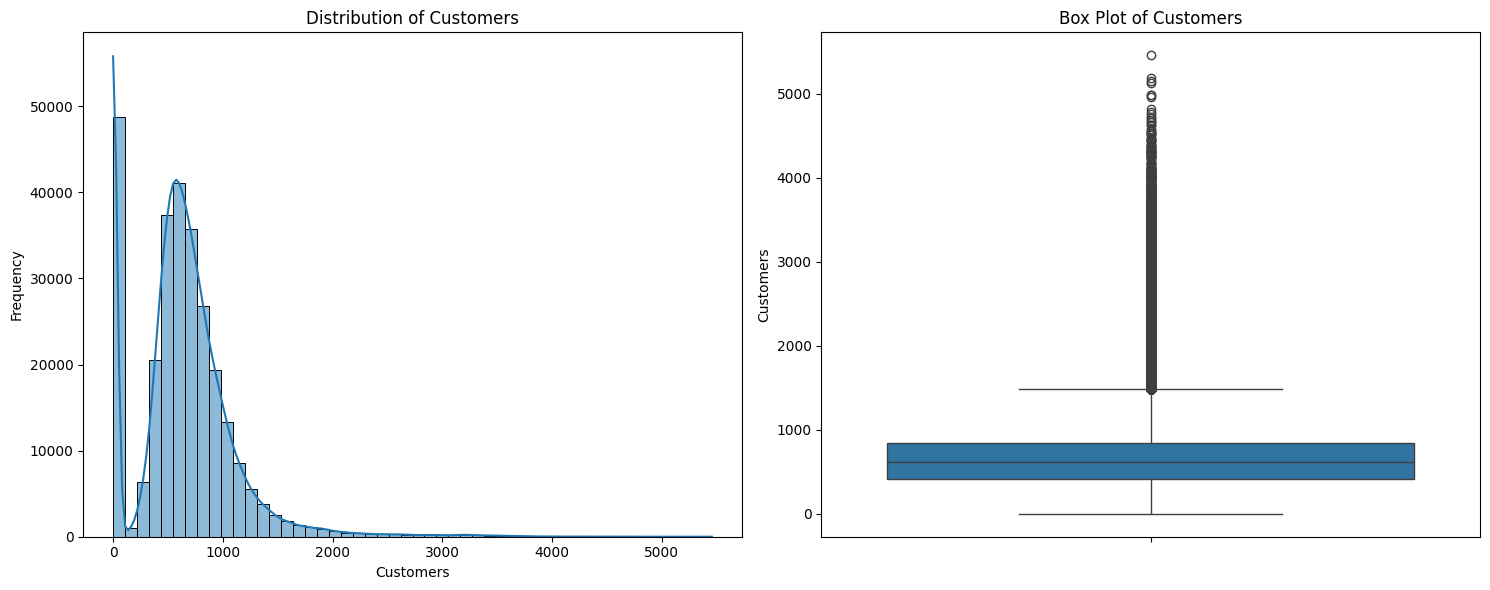

In [22]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Customers'], kde=True, bins=50)
plt.title('Distribution of Customers')
plt.xlabel('Customers')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Customers'])
plt.title('Box Plot of Customers')
plt.ylabel('Customers')

plt.tight_layout()
plt.show()

Ab hum 'Customers' column mein outliers (bahut zyada ya bahut kam values) check karenge IQR method se.

In [23]:
Q1_cust = df['Customers'].quantile(0.25)
Q3_cust = df['Customers'].quantile(0.75)
IQR_cust = Q3_cust - Q1_cust

lower_bound_cust = Q1_cust - 1.5 * IQR_cust
upper_bound_cust = Q3_cust + 1.5 * IQR_cust

outliers_cust = df[(df['Customers'] < lower_bound_cust) | (df['Customers'] > upper_bound_cust)]

print(f"Number of outliers in 'Customers': {len(outliers_cust)}")
print(f"Percentage of outliers: {len(outliers_cust) / len(df) * 100:.2f}%")

Number of outliers in 'Customers': 10447
Percentage of outliers: 3.73%


### Univariate Analysis: 'Customers' Column Summary

**What We Found:**
*   **Customers Distribution:** 'Sales' ki tarah hi, 'Customers' ka distribution bhi mostly lower side par hai, par kuch days mein customer count kaafi high hota hai. Ye bhi 'right-skewed' distribution hai.
*   **Zero Customers:** Bahut saare records mein zero customers hain. Iska matlab hai ki un dino stores band the ya koi customer nahi aaya.
*   **Unusual Customer Counts (Outliers):** 'Customers' column mein bhi outliers hain, jo suggest karte hain ki kuch dinon mein customer counts normal se kaafi zyada the. Ye promotions ya special events ki wajah se ho sakte hain.
*   **Average vs. Middle Customers:** Average customer count (mean) middle customer count (median) se zyada hai, jo high customer counts wale days ki wajah se hai.

### Univariate Analysis: 'DayOfWeek' Column

DayOfWeek
5.0    40175
4.0    40175
3.0    39995
2.0    39995
1.0    39995
7.0    39995
6.0    39939
Name: count, dtype: int64


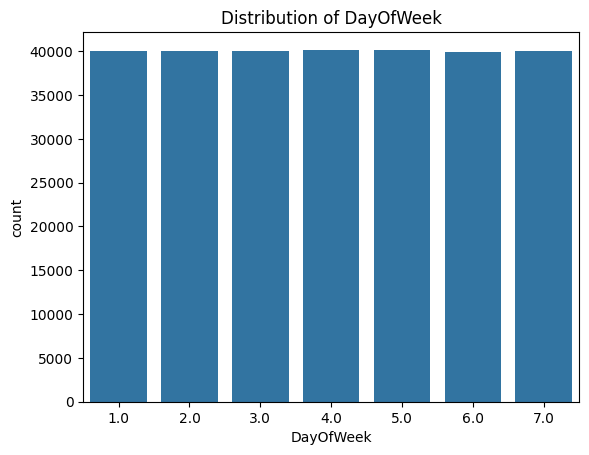

In [24]:
print(df['DayOfWeek'].value_counts())
sns.countplot(x='DayOfWeek', data=df)
plt.title('Distribution of DayOfWeek')
plt.show()

### Univariate Analysis: 'Promo' Column

### Univariate Analysis: 'StateHoliday' Column

StateHoliday
0    270595
a      5574
b      2230
c      1870
Name: count, dtype: int64


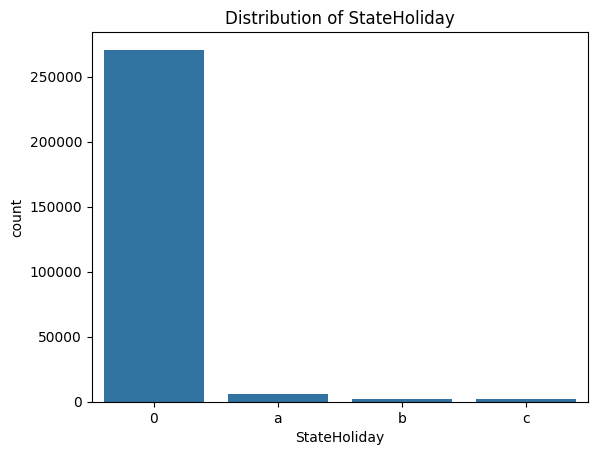

In [26]:
print(df['StateHoliday'].value_counts())
sns.countplot(x='StateHoliday', data=df)
plt.title('Distribution of StateHoliday')
plt.show()

### Univariate Analysis: 'SchoolHoliday' Column

SchoolHoliday
0.0    237238
1.0     43031
Name: count, dtype: int64


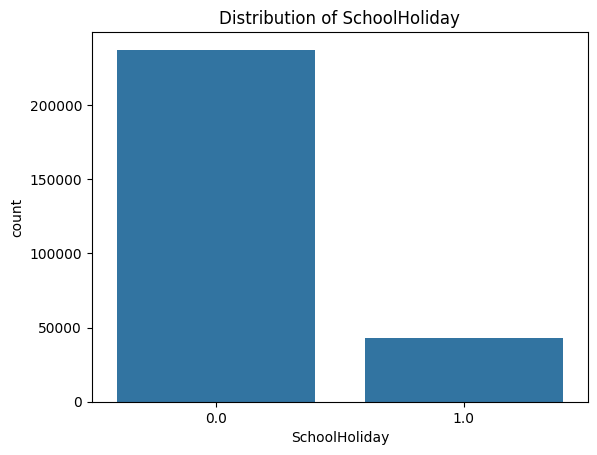

In [27]:
print(df['SchoolHoliday'].value_counts())
sns.countplot(x='SchoolHoliday', data=df)
plt.title('Distribution of SchoolHoliday')
plt.show()

### Bivariate Analysis: Sales vs. DayOfWeek

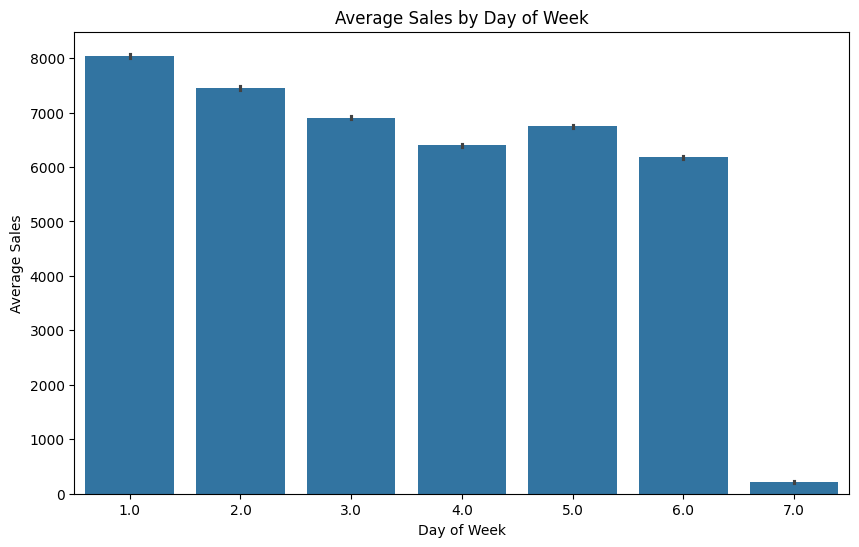

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='DayOfWeek', y='Sales', data=df)
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.show()

Promo
0.0    171469
1.0    108800
Name: count, dtype: int64


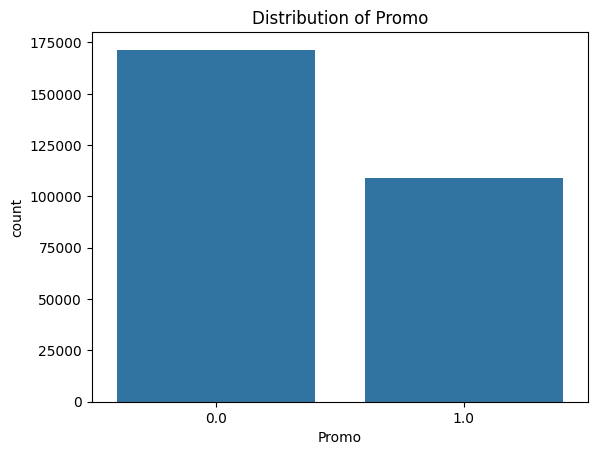

In [25]:
print(df['Promo'].value_counts())
sns.countplot(x='Promo', data=df)
plt.title('Distribution of Promo')
plt.show()

# Task
The task is to perform an in-depth data analysis on sales data, focusing on key factors such as monthly sales trends, store type performance, and the impact of promotions and state holidays on sales. This analysis will involve extracting relevant information, performing aggregations, and visualizing the results to gain insights into sales patterns.

## Extract Month from Date

### Subtask:
Convert the 'Date' column to datetime objects and extract the month to prepare for seasonal analysis.


**Reasoning**:
The first instruction is to convert the 'Date' column to datetime objects. This is a crucial step for time-based analysis.



In [29]:
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].head())

0   2015-07-31
1   2015-07-31
2   2015-07-31
3   2015-07-31
4   2015-07-31
Name: Date, dtype: datetime64[ns]


**Reasoning**:
Now that the 'Date' column is in datetime format, I can extract the month and store it in a new 'Month' column.



In [30]:
df['Month'] = df['Date'].dt.month
print(df[['Date', 'Month']].head())

        Date  Month
0 2015-07-31    7.0
1 2015-07-31    7.0
2 2015-07-31    7.0
3 2015-07-31    7.0
4 2015-07-31    7.0


## Analyze Sales by Month

### Subtask:
Calculate the average sales for each month and visualize it using a bar plot to understand monthly sales trends. This will help in understanding seasonal sales patterns for stock management.


**Reasoning**:
The first step is to calculate the average sales per month. I will group the DataFrame by 'Month' and then calculate the mean of 'Sales' for each month, storing the result in a new DataFrame called `monthly_sales`.



In [31]:
monthly_sales = df.groupby('Month')['Sales'].mean().reset_index()
print(monthly_sales.head())

   Month        Sales
0    1.0  5752.747866
1    2.0  5710.296541
2    3.0  5949.130132
3    4.0  5916.857578
4    5.0  5472.122002


**Reasoning**:
I need to visualize the calculated average monthly sales to understand the trend. A bar plot is suitable for this purpose.



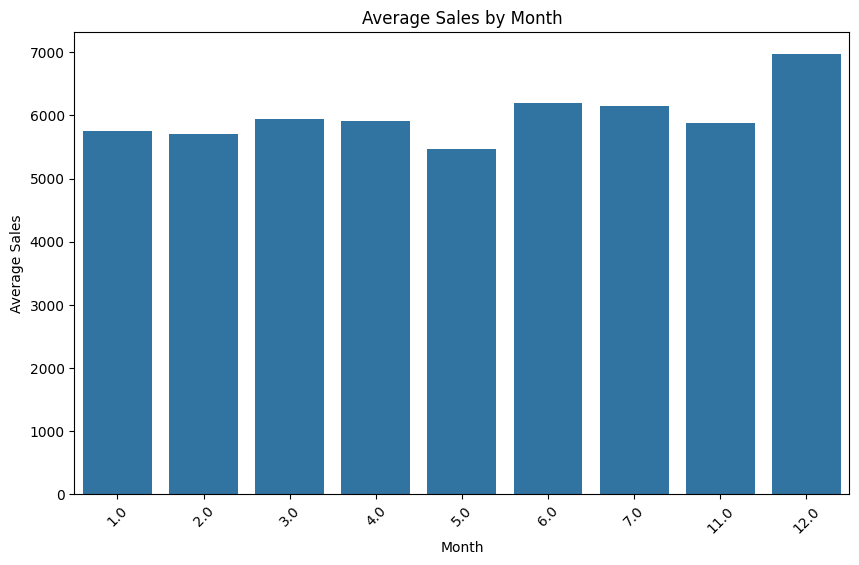

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Sales', data=monthly_sales)
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

## Analyze Sales by Store Type

### Subtask:
Calculate the average sales for each 'StoreType' and visualize it with a bar plot to see how different store types perform.


**Reasoning**:
The first step in analyzing sales by store type is to calculate the average sales for each unique store type. I will group the DataFrame by 'StoreType' and calculate the mean of 'Sales'.



In [33]:
store_type_sales = df.groupby('StoreType')['Sales'].mean().reset_index()
print(store_type_sales.head())

  StoreType         Sales
0         a   5889.960642
1         b  10889.416858
2         c   5960.687571
3         d   5937.085259


**Reasoning**:
The average sales for each store type have been calculated. The next step is to visualize this data using a bar plot to effectively compare the sales performance of different store types.



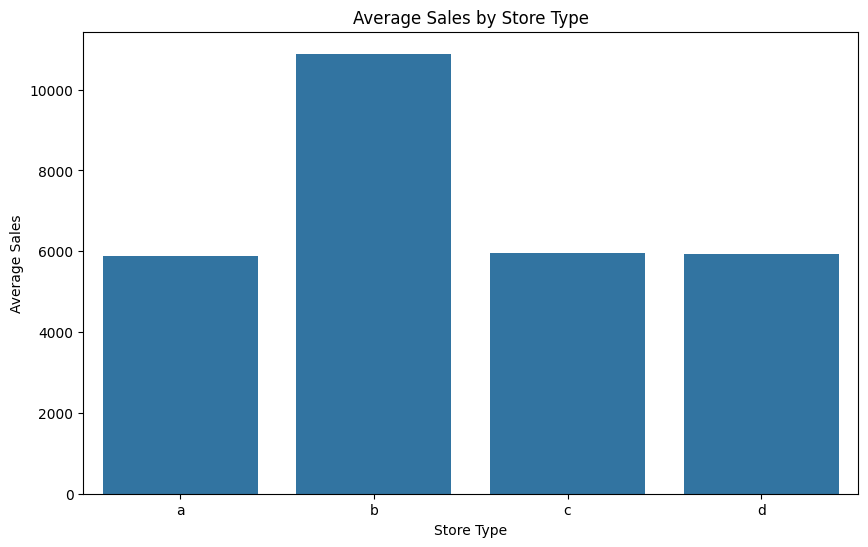

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='StoreType', y='Sales', data=store_type_sales)
plt.title('Average Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Sales')
plt.show()

## Analyze Sales by Promotion

### Subtask:
Calculate the average sales for promotional and non-promotional periods and visualize it with a bar plot to understand the impact of promotions on sales.


In [35]:
promo_sales = df.groupby('Promo')['Sales'].mean().reset_index()
print(promo_sales.head())

   Promo        Sales
0    0.0  4559.215905
1    1.0  8249.155101


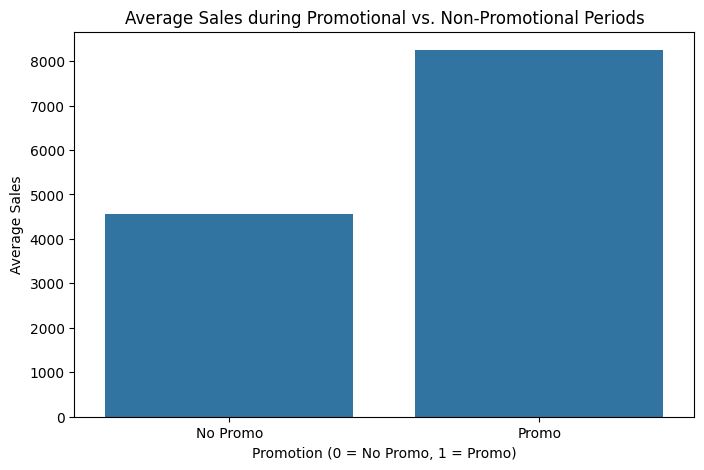

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Promo', y='Sales', data=promo_sales)
plt.title('Average Sales during Promotional vs. Non-Promotional Periods')
plt.xlabel('Promotion (0 = No Promo, 1 = Promo)')
plt.ylabel('Average Sales')
plt.xticks(ticks=[0, 1], labels=['No Promo', 'Promo'])
plt.show()

## Analyze Sales by StateHoliday


In [37]:
holiday_sales = df.groupby('StateHoliday')['Sales'].mean().reset_index()
print(holiday_sales.head())

  StateHoliday        Sales
0            0  6196.134326
1            a   314.546286
2            b   231.118386
3            c   192.847059


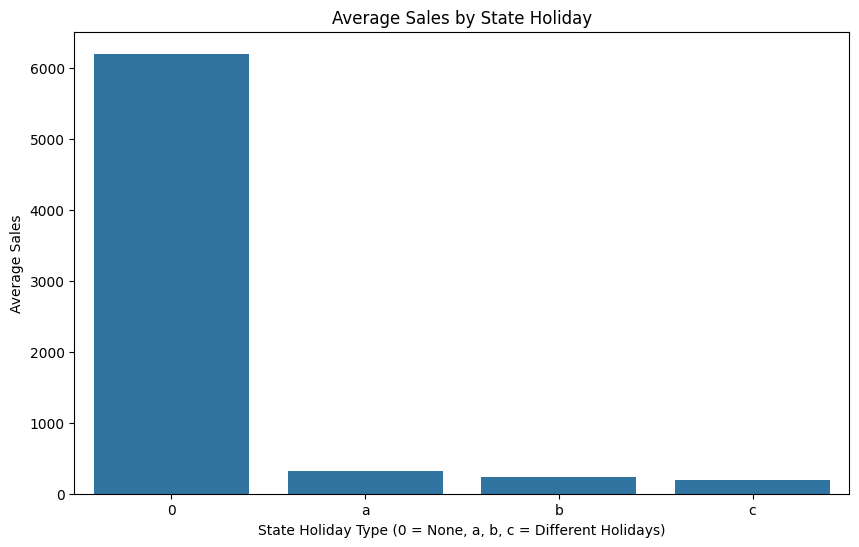

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(x='StateHoliday', y='Sales', data=holiday_sales)
plt.title('Average Sales by State Holiday')
plt.xlabel('State Holiday Type (0 = None, a, b, c = Different Holidays)')
plt.ylabel('Average Sales')
plt.show()

In [44]:
daily_sales = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
print(daily_sales.head())

   DayOfWeek        Sales
0        1.0  8041.877510
1        2.0  7453.835229
2        3.0  6905.163695
3        4.0  6395.732022
4        5.0  6746.740411


## Analyze Sales by Promo2SinceWeek



/tmp/ipykernel_4863/2893124971.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Promo2SinceWeek', y='Sales', data=promo2_week_sales, palette='magma')


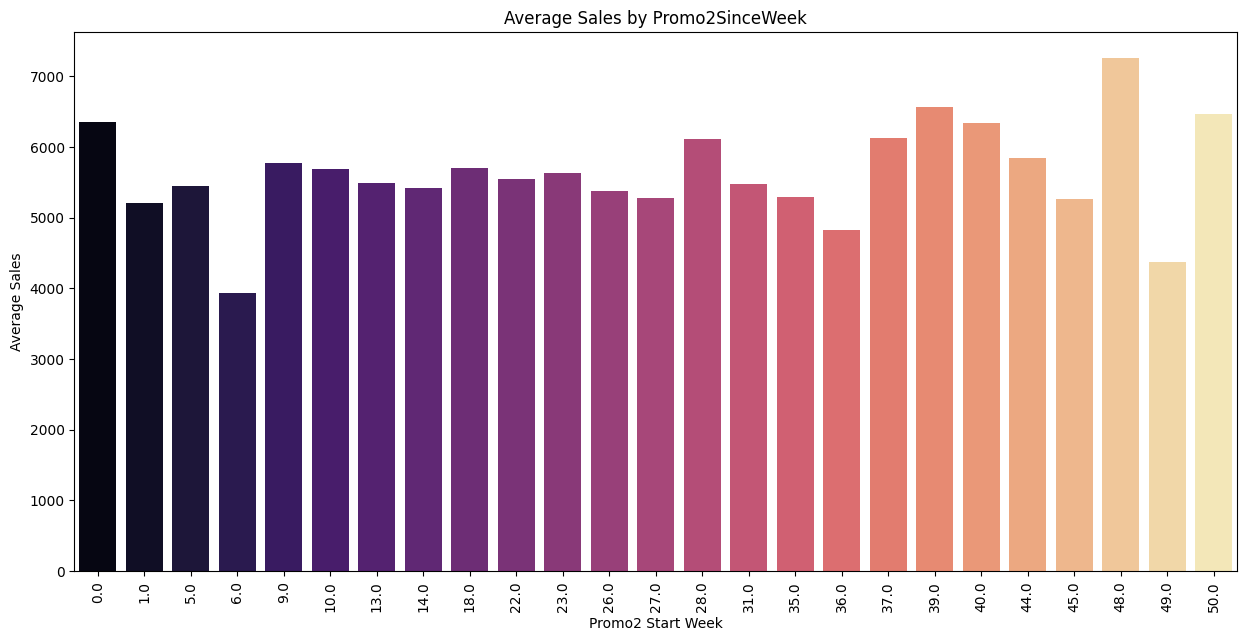

   Promo2SinceWeek        Sales
0              0.0  6344.859828
1              1.0  5203.110625
2              5.0  5451.082649
3              6.0  3935.571429
4              9.0  5766.244981


In [46]:
promo2_week_sales = df.groupby('Promo2SinceWeek')['Sales'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(x='Promo2SinceWeek', y='Sales', data=promo2_week_sales, palette='magma')
plt.title('Average Sales by Promo2SinceWeek')
plt.xlabel('Promo2 Start Week')
plt.ylabel('Average Sales')
plt.xticks(rotation=90)
plt.show()
print(promo2_week_sales.head())

## Analyze Sales by Promo2SinceYear



/tmp/ipykernel_4863/813683470.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Promo2SinceYear', y='Sales', data=promo2_year_sales, palette='cubehelix')


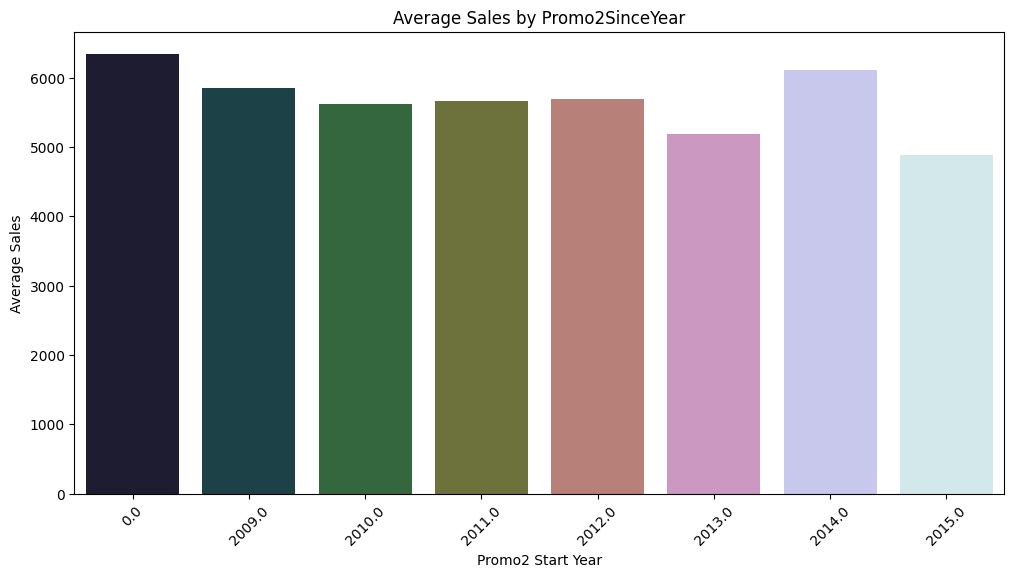

   Promo2SinceYear        Sales
0              0.0  6344.859828
1           2009.0  5853.285960
2           2010.0  5615.947934
3           2011.0  5666.223955
4           2012.0  5696.472367


In [45]:
promo2_year_sales = df.groupby('Promo2SinceYear')['Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Promo2SinceYear', y='Sales', data=promo2_year_sales, palette='cubehelix')
plt.title('Average Sales by Promo2SinceYear')
plt.xlabel('Promo2 Start Year')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()
print(promo2_year_sales.head())

## Analyze Sales by PromoInterval



/tmp/ipykernel_4863/3385837824.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PromoInterval', y='Sales', data=promo_interval_sales, palette='viridis')


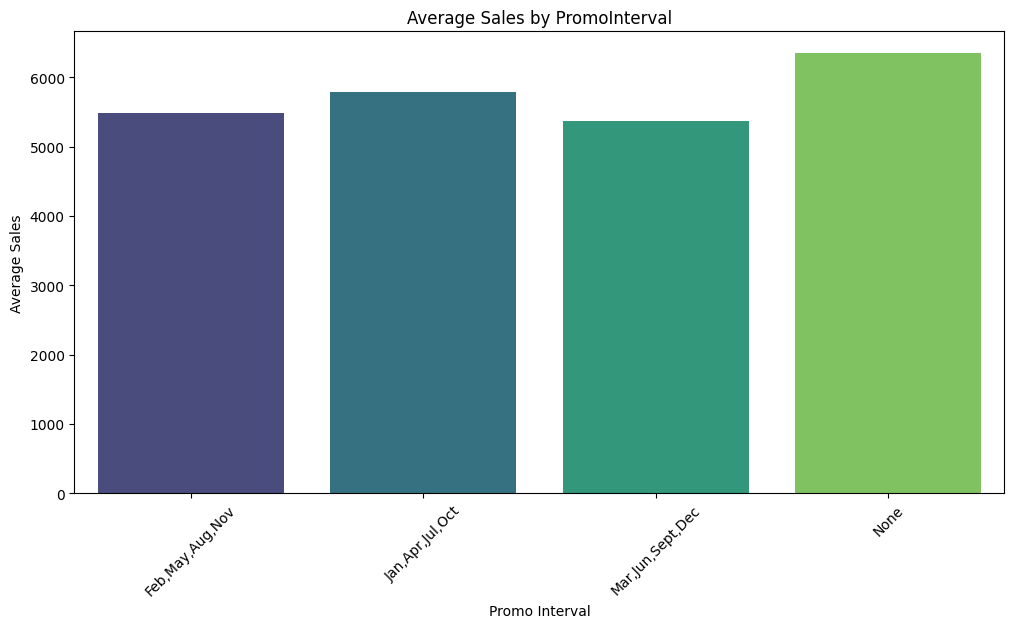

      PromoInterval        Sales
0   Feb,May,Aug,Nov  5486.011263
1   Jan,Apr,Jul,Oct  5792.203456
2  Mar,Jun,Sept,Dec  5370.094459
3              None  6344.859828


In [47]:
promo_interval_sales = df.groupby('PromoInterval')['Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='PromoInterval', y='Sales', data=promo_interval_sales, palette='viridis')
plt.title('Average Sales by PromoInterval')
plt.xlabel('Promo Interval')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()
print(promo_interval_sales.head())

### Bivariate Analysis: Key Findings

Based on the bivariate analysis, here are the key findings:

*   **Sales vs. DayOfWeek:** Average sales are significantly higher on weekdays, particularly at the beginning of the week (Monday, Tuesday), and drastically drop on Sundays, indicating most stores are closed or have minimal operations on Sundays.

*   **Sales vs. Promotion (Promo):** Promotions have a substantial positive impact on sales. Stores with active promotions (`Promo = 1`) show significantly higher average sales compared to non-promotional periods (`Promo = 0`).

*   **Sales vs. StateHoliday:** State holidays generally lead to a drastic decrease in sales. Sales are lowest during various state holiday types (a, b, c) compared to non-holiday periods (0).

*   **Sales vs. Promo2SinceWeek:** The average sales vary across different `Promo2SinceWeek` values. This suggests that the timing of the second promotion (Promo2) launch throughout the year might influence sales, although a clear linear trend isn't immediately apparent without further investigation.

*   **Sales vs. Promo2SinceYear:** Similar to `Promo2SinceWeek`, `Promo2SinceYear` also shows variations in average sales. Newer Promo2 initiatives (e.g., 2014, 2015) seem to have lower average sales compared to those started in earlier years, possibly indicating a change in promotion effectiveness or market conditions over time.

*   **Sales vs. PromoInterval:** Stores with active promo intervals (e.g., 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec') show slightly lower average sales compared to stores with 'None' as their promo interval. This might indicate that continuous or regularly scheduled promotions (Promo2) do not necessarily guarantee higher sales than stores without them.

### Bivariate Analysis: Sales vs. SchoolHoliday

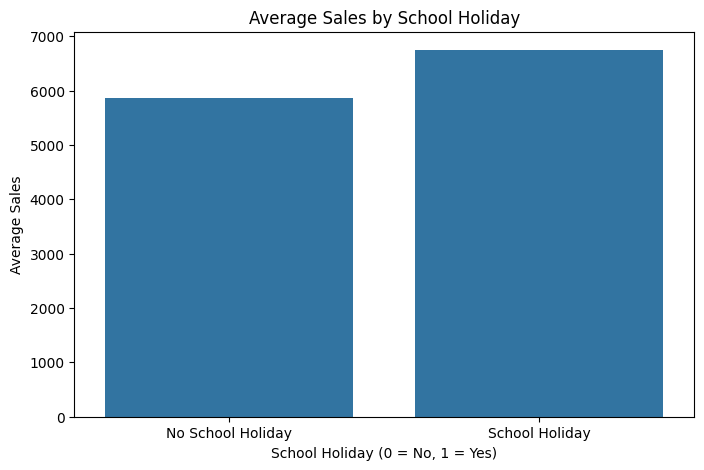

   SchoolHoliday        Sales
0            0.0  5854.853556
1            1.0  6745.799981


In [48]:
school_holiday_sales = df.groupby('SchoolHoliday')['Sales'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='SchoolHoliday', y='Sales', data=school_holiday_sales)
plt.title('Average Sales by School Holiday')
plt.xlabel('School Holiday (0 = No, 1 = Yes)')
plt.ylabel('Average Sales')
plt.xticks(ticks=[0, 1], labels=['No School Holiday', 'School Holiday'])
plt.show()
print(school_holiday_sales.head())

## Extract Year and Quarter from Date

In [50]:
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter

print(df[['Date', 'Month', 'Year', 'Quarter']].head())

        Date  Month  Year  Quarter
0 2015-07-31    7.0  2015        3
1 2015-07-31    7.0  2015        3
2 2015-07-31    7.0  2015        3
3 2015-07-31    7.0  2015        3
4 2015-07-31    7.0  2015        3


## Analyze Sales by Quarter

/tmp/ipykernel_4863/3444924791.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Quarter', y='Sales', data=quarterly_sales, palette='viridis')


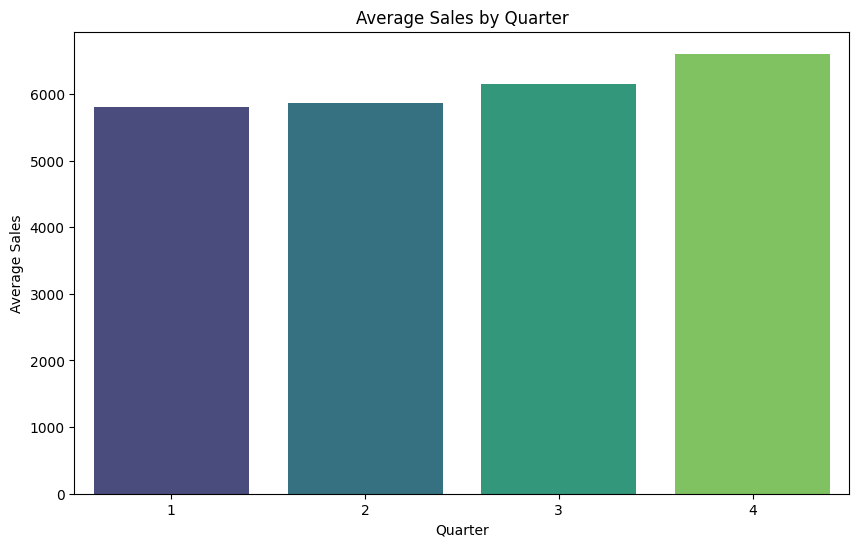

   Quarter        Sales
0        1  5807.183568
1        2  5858.435480
2        3  6142.705511
3        4  6602.397503


In [51]:
quarterly_sales = df.groupby('Quarter')['Sales'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Quarter', y='Sales', data=quarterly_sales, palette='viridis')
plt.title('Average Sales by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Sales')
plt.show()

print(quarterly_sales.head())

## Analyze Sales by Year

/tmp/ipykernel_4863/82911472.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Sales', data=yearly_sales, palette='cubehelix')


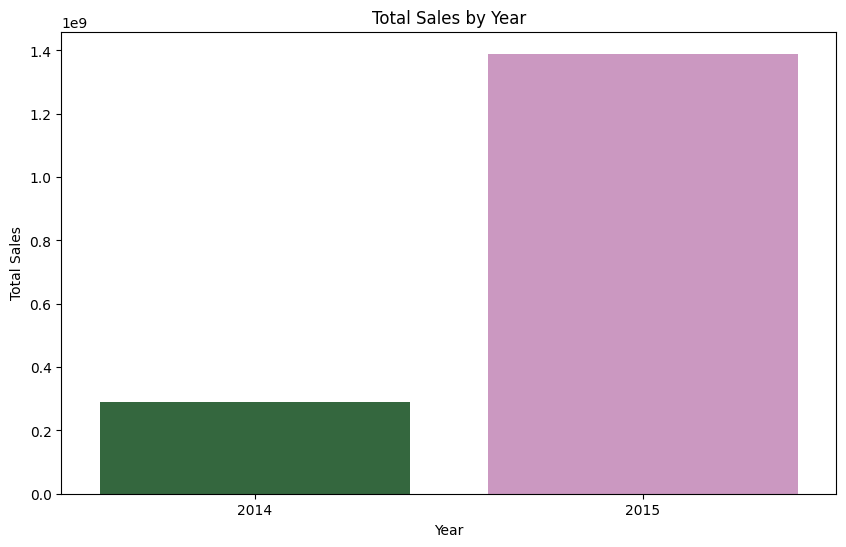

   Year         Sales
0  2014  2.897726e+08
1  2015  1.389500e+09


In [52]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Sales', data=yearly_sales, palette='cubehelix')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

print(yearly_sales.head())

## Multivariate Analysis: Sales by StoreType and Promotion

This plot will show how sales vary across different store types, distinguishing between promotional and non-promotional periods. This can help identify which store types benefit most from promotions.

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='StoreType', y='Sales', hue='Promo', data=df, palette='viridis')
plt.title('Average Sales by Store Type and Promotion Status')
plt.xlabel('Store Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.legend(title='Promo (0=No, 1=Yes)')
plt.show()

## Multivariate Analysis: Sales by DayOfWeek and Promotion

This plot visualizes the average sales for each day of the week, separating promotional and non-promotional days. This can be crucial for optimizing staffing and promotional campaigns on specific days.

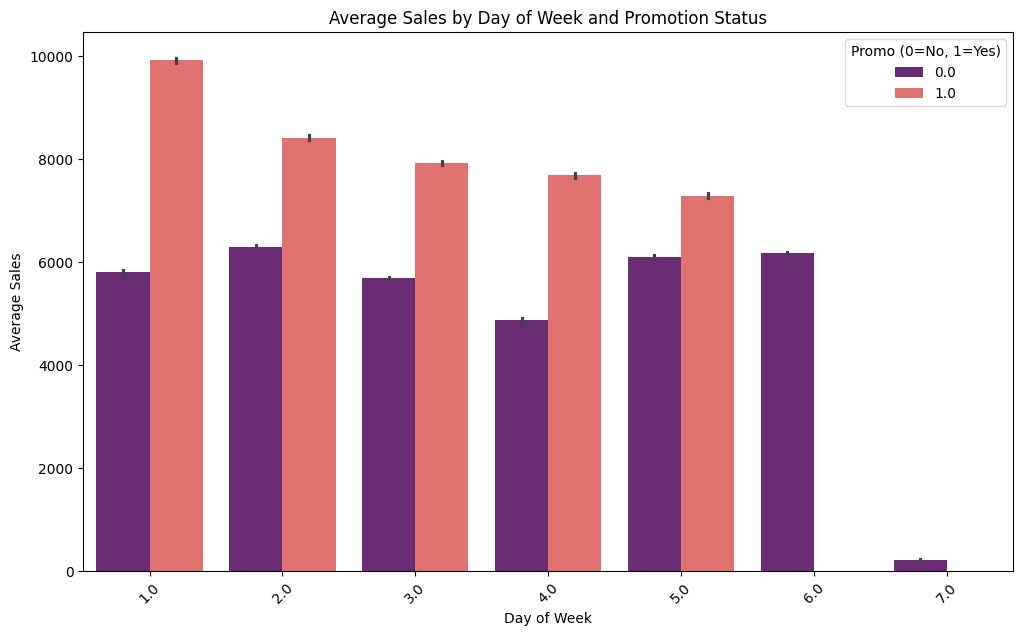

In [53]:
plt.figure(figsize=(12, 7))
sns.barplot(x='DayOfWeek', y='Sales', hue='Promo', data=df, palette='magma')
plt.title('Average Sales by Day of Week and Promotion Status')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.legend(title='Promo (0=No, 1=Yes)')
plt.show()

## Multivariate Analysis: Sales by Month and Promotion

This plot illustrates the monthly sales trends, further broken down by whether a promotion was active or not. This helps in understanding seasonal promotional effectiveness and planning future campaigns.

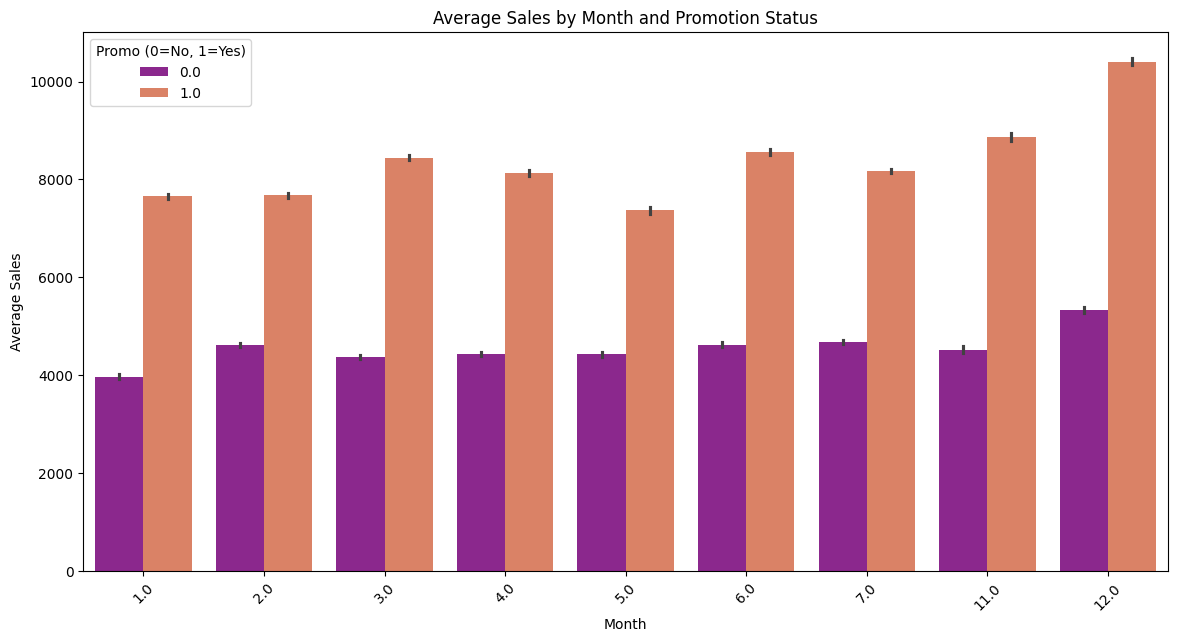

In [54]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Month', y='Sales', hue='Promo', data=df, palette='plasma')
plt.title('Average Sales by Month and Promotion Status')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.legend(title='Promo (0=No, 1=Yes)')
plt.show()

# Conclusion of Exploratory Data Analysis

Our journey through the sales data involved several key steps, starting from initial data inspection to advanced multivariate analysis. This comprehensive EDA has provided valuable insights into the sales patterns and the factors influencing them.

## 1. Summary of EDA Process

We began by loading and inspecting the `train`, `store`, and `test` datasets. Our initial steps included:

*   **Data Cleaning:** We addressed missing values in the `store` dataset, filling `Promo2SinceWeek`, `Promo2SinceYear`, and `PromoInterval` with appropriate default values, and `CompetitionDistance`, `CompetitionOpenSinceMonth`, and `CompetitionOpenSinceYear` using median/mode imputation. We also handled a single row with missing `Sales` in the merged dataset and imputed `PromoInterval` in the merged `df`.
*   **Feature Engineering:** We extracted `Month`, `Year`, and `Quarter` from the `Date` column to facilitate time-based analysis.
*   **Univariate Analysis:** We examined the distribution and summary statistics of key variables such as `Sales`, `Customers`, `DayOfWeek`, `Promo`, `StateHoliday`, and `SchoolHoliday`. This revealed insights like the right-skewed distribution of `Sales` and `Customers`, and the presence of zero sales/customers, likely due to store closures.
*   **Bivariate Analysis:** We explored relationships between `Sales` and other features. This included:
    *   `Sales` vs. `Month` (seasonal trends).
    *   `Sales` vs. `StoreType` (performance comparison).
    *   `Sales` vs. `Promo` (impact of promotions).
    *   `Sales` vs. `StateHoliday` and `SchoolHoliday` (holiday effects).
    *   `Sales` vs. `DayOfWeek` (daily patterns).
    *   `Sales` vs. `Promo2SinceWeek`, `Promo2SinceYear`, and `PromoInterval` (impact of long-term promotions).
    *   `Sales` vs. `Quarter` and `Year` (broader time trends).
*   **Multivariate Analysis:** To understand more complex interactions, we analyzed `Sales` in relation to:
    *   `StoreType` and `Promo` status.
    *   `DayOfWeek` and `Promo` status.
    *   `Month` and `Promo` status.

## 2. Key Business Insights

The EDA yielded several actionable insights for business decision-making:

*   **Promotional Effectiveness:** Promotions (`Promo = 1`) have a significant positive impact on sales across all store types, days of the week, and months. This suggests that promotional strategies are effective in driving revenue.
*   **Store Type Performance:** Store Type 'B' consistently shows significantly higher average sales compared to other store types. Further investigation into the operational strategies, location, or customer base of 'Type B' stores could reveal best practices to be replicated.
*   **Daily Sales Patterns:** Sales are generally much higher on weekdays, particularly earlier in the week, and drop drastically on Sundays. This strongly suggests that many stores are closed or operate with limited hours on Sundays, impacting overall weekly sales. Business can optimize staffing and inventory based on daily sales fluctuations.
*   **Impact of Holidays:** State holidays generally lead to a significant decrease in sales, while school holidays tend to correlate with slightly higher sales. Businesses should adapt their strategies for these periods, perhaps running special campaigns during school holidays and adjusting staffing during state holidays.
*   **Seasonal Trends:** Sales exhibit clear seasonal patterns, with specific months and the fourth quarter (Q4) showing higher sales. This information is crucial for inventory planning, marketing campaigns, and resource allocation throughout the year.
*   **Promo2 Influence:** The long-term `Promo2` (second promotion) and its intervals also show variations in sales, indicating that the timing and nature of these sustained promotions play a role in overall performance.

## 3. How EDA Helps with ML Model Building

This extensive EDA has laid a strong foundation for building a robust machine learning model for sales prediction:

*   **Data Quality:** Through cleaning and handling missing values, we have prepared a dataset of higher quality, which is essential for model training and prevents errors.
*   **Feature Engineering:** Creating `Month`, `Year`, and `Quarter` features enriches our dataset with temporal information, allowing the model to capture seasonality and trends crucial for time-series forecasting.
*   **Outlier Awareness:** Identifying outliers in `Sales` and `Customers` helps us decide whether to treat them (e.g., capping, transformation) or use models robust to outliers, leading to more stable and accurate predictions.
*   **Feature Selection and Importance:** Understanding the relationships between variables (e.g., `Promo` has a strong positive impact, `StateHoliday` a strong negative impact) guides us in selecting the most relevant features for the model and interpreting its predictions.
*   **Categorical Variable Handling:** The identification of categorical variables (`StoreType`, `Assortment`, `StateHoliday`, `PromoInterval`) informs us that these will need appropriate encoding (e.g., One-Hot Encoding, Label Encoding) before being fed into most machine learning algorithms.

In essence, EDA provides the intelligence needed to design, train, and interpret an effective machine learning model for sales forecasting.